In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# --- 1. Configuration & Reproducibility ---
BATCH_SIZE = 42
SEED = 42
EPOCHS = 50

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

In [ ]:
# ====================== Set Seed ======================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [ ]:
# 1. Model Definition
class KeypointNet(nn.Module):
    def __init__(self, input_dim=51, num_classes=2):
        super(KeypointNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
# --- 2. Data Preparation ---
def load_and_preprocess(file_path, scaler=None, is_train=False):
    df = pd.read_csv(file_path)
    # Features: keypoint coordinates and visibility (cols 2 to end)
    X = df.iloc[:, 2:].values
    # Labels: cat_id (col 1), map {1, 2} -> {0, 1}
    y = df.iloc[:, 1].values - 1

    if is_train:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        return X, y, scaler
    else:
        X = scaler.transform(X)
        return X, y

# Load datasets
X_train, y_train, scaler = load_and_preprocess('keypoint_train_data.csv', is_train=True)
X_valid, y_valid = load_and_preprocess('keypoint_valid_data.csv', scaler=scaler)
X_test, y_test = load_and_preprocess('keypoint_test_data.csv', scaler=scaler)

class KeypointDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(KeypointDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(KeypointDataset(X_valid, y_valid), batch_size=BATCH_SIZE)
test_loader = DataLoader(KeypointDataset(X_test, y_test), batch_size=BATCH_SIZE)

In [ ]:
# --- 3. Model Architecture (KeypointNet) ---
class KeypointNet(nn.Module):
    def __init__(self, input_dim=51, num_classes=2):
        super(KeypointNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

model = KeypointNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Initialize a dictionary to store history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100. * correct_train / total_train

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = 100. * correct_val / total_val

    # Save metrics to history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

Epoch 1/50: Train Loss: 0.1003, Train Acc: 96.66%, Val Loss: 0.4683, Val Acc: 84.36%
Epoch 2/50: Train Loss: 0.1188, Train Acc: 95.60%, Val Loss: 0.4245, Val Acc: 86.03%
Epoch 3/50: Train Loss: 0.1183, Train Acc: 95.67%, Val Loss: 0.4409, Val Acc: 86.03%
Epoch 4/50: Train Loss: 0.1397, Train Acc: 94.31%, Val Loss: 0.4293, Val Acc: 85.47%
Epoch 5/50: Train Loss: 0.1149, Train Acc: 94.99%, Val Loss: 0.4177, Val Acc: 86.59%
Epoch 6/50: Train Loss: 0.1225, Train Acc: 95.52%, Val Loss: 0.3674, Val Acc: 87.71%
Epoch 7/50: Train Loss: 0.1209, Train Acc: 95.14%, Val Loss: 0.3969, Val Acc: 87.15%
Epoch 8/50: Train Loss: 0.1025, Train Acc: 95.82%, Val Loss: 0.4274, Val Acc: 86.03%
Epoch 9/50: Train Loss: 0.0936, Train Acc: 96.13%, Val Loss: 0.4275, Val Acc: 84.36%
Epoch 10/50: Train Loss: 0.1154, Train Acc: 95.67%, Val Loss: 0.4244, Val Acc: 88.27%
Epoch 11/50: Train Loss: 0.0990, Train Acc: 96.20%, Val Loss: 0.4950, Val Acc: 84.36%
Epoch 12/50: Train Loss: 0.1090, Train Acc: 96.28%, Val Loss: 0

In [ ]:
# --- 5. Evaluation ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final Results
print("\n--- Final Test Results ---")
print(f"Accuracy: {np.mean(np.array(all_preds) == np.array(all_labels)) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Posture 1', 'Posture 2']))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


--- Final Test Results ---
Accuracy: 87.64%

Classification Report:
              precision    recall  f1-score   support

   Posture 1       0.80      0.98      0.88        41
   Posture 2       0.97      0.79      0.87        48

    accuracy                           0.88        89
   macro avg       0.89      0.88      0.88        89
weighted avg       0.89      0.88      0.88        89


Confusion Matrix:
[[40  1]
 [10 38]]


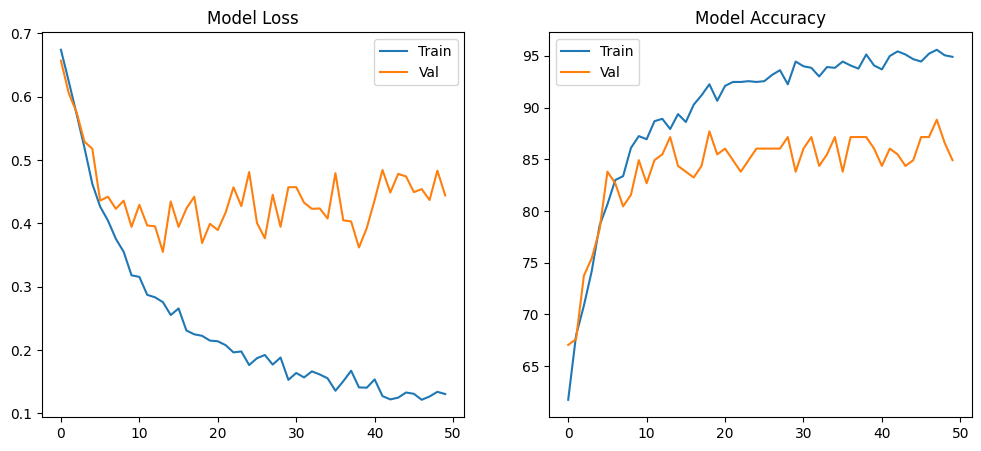

In [ ]:
# --- 6. Visualization (Graphs) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Model Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title('Model Accuracy'); plt.legend()
plt.savefig('training_curves.png')

              precision    recall  f1-score   support

     Class 1       0.80      0.98      0.88        41
     Class 2       0.97      0.79      0.87        48

    accuracy                           0.88        89
   macro avg       0.89      0.88      0.88        89
weighted avg       0.89      0.88      0.88        89



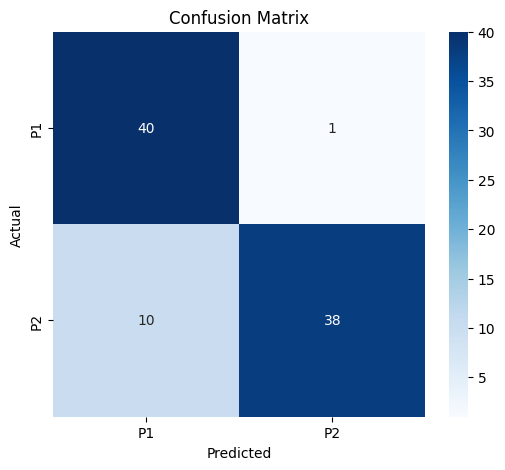

In [ ]:
# --- 7. Final Evaluation & Confusion Matrix ---
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Classification Report
print(classification_report(all_labels, all_preds, target_names=['Class 1', 'Class 2']))

# Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['P1', 'P2'], yticklabels=['P1', 'P2'])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')